In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

In [3]:
df = pd.read_csv('E:\Stock-Price-Prediction\stock_data.csv')
df.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


In [4]:
df.shape

(365, 6)

In [5]:
df.columns

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='str')

In [6]:
df = df.drop_duplicates(keep= False , ignore_index=True)

In [7]:
df.head(5)

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


[]

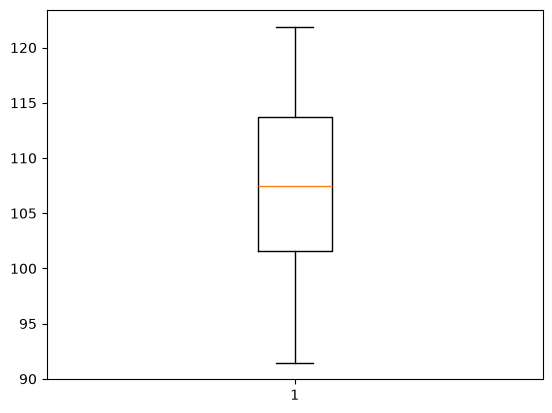

In [8]:
plt.boxplot(df['Stock_1'], label='Stock_1 Outlier_graph')
plt.plot()

[]

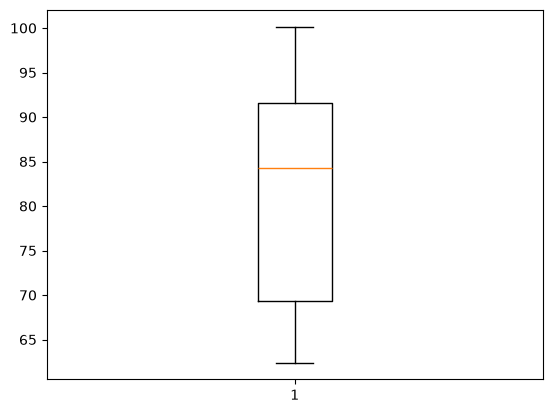

In [9]:
plt.boxplot(df['Stock_2'], label='Stock_2 Outlier_graph')
plt.plot()

[]

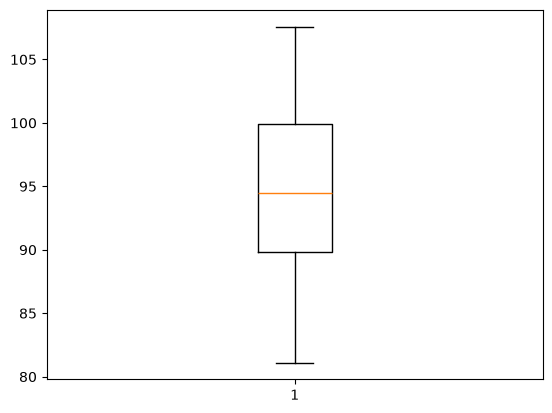

In [10]:
plt.boxplot(df['Stock_3'], label='Stock_3 Outlier_graph')
plt.plot()

[]

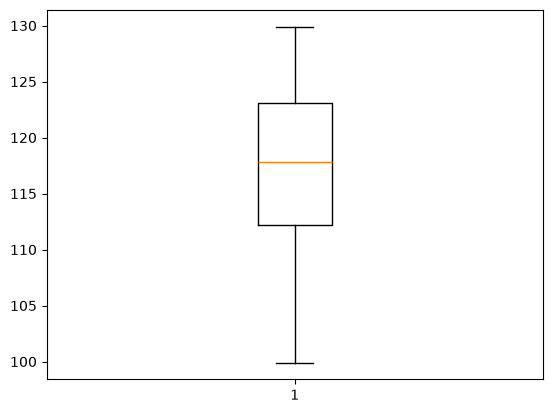

In [11]:
plt.boxplot(df['Stock_4'], label='Stock_4 Outlier_graph')
plt.plot()

[]

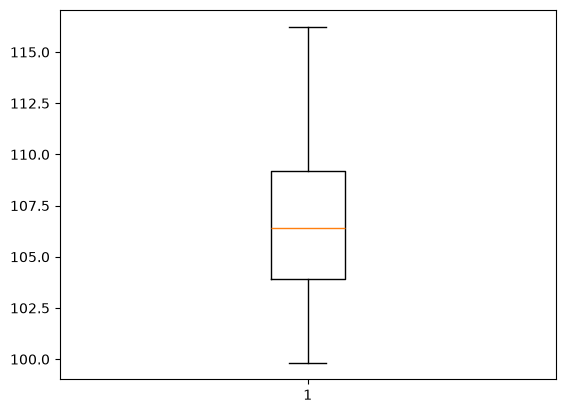

In [12]:
plt.boxplot(df['Stock_5'], label='Stock_5 Outlier_graph')
plt.plot()

In [13]:
import scipy
from scipy import stats

In [14]:
independent_variable =df.copy()

In [15]:
independent_variable['Stock_1'] = stats.zscore(independent_variable['Stock_1'], ddof=1 )
independent_variable['Stock_1'].head(10)

0   -0.812150
1   -0.757108
2   -0.621943
3   -0.309444
4   -0.043172
5   -0.185113
6   -0.048470
7   -0.070445
8   -0.085408
9   -0.025946
Name: Stock_1, dtype: float64

In [16]:
independent_variable['Stock_2'] = stats.zscore(independent_variable['Stock_2'], ddof=1 )
independent_variable['Stock_2'].head(10)


0    1.666407
1    1.649707
2    1.615188
3    1.591875
4    1.493913
5    1.517993
6    1.432479
7    1.504229
8    1.482784
9    1.487028
Name: Stock_2, dtype: float64

In [17]:
independent_variable['Stock_3'] = stats.zscore(independent_variable['Stock_3'], ddof=1 )
independent_variable['Stock_3'].head(10)

0    0.763150
1    0.638646
2    0.561822
3    0.403404
4    0.775537
5    0.432584
6    0.516797
7    0.323916
8    0.308450
9    0.162156
Name: Stock_3, dtype: float64

In [18]:
independent_variable['Stock_4'] = stats.zscore(independent_variable['Stock_4'], ddof=1 )
independent_variable['Stock_4'].head(10)

0   -2.581358
1   -2.473517
2   -2.483240
3   -2.431582
4   -2.332830
5   -2.498386
6   -2.502971
7   -2.269022
8   -2.388757
9   -2.473337
Name: Stock_4, dtype: float64

In [19]:
independent_variable['Stock_5'] = stats.zscore(independent_variable['Stock_5'], ddof=1 )
independent_variable['Stock_5'].head(10)

0   -1.357522
1   -1.153485
2   -1.323875
3   -1.429636
4   -1.399262
5   -1.576361
6   -1.558240
7   -1.349403
8   -1.359077
9   -1.268166
Name: Stock_5, dtype: float64

In [20]:
independent_variable.rename(columns={'Unnamed: 0':'Time'},inplace=True)
print(independent_variable.columns)

Index(['Time', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='str')


In [21]:
# sort data by time 

independent_variable = independent_variable.sort_values(by="Time", ignore_index=True)
independent_variable.shape

(365, 6)

In [23]:
independent_variable.head(5)

,Time,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,-0.812150,1.666407,0.763150,-2.581358,-1.357522
1,2020-01-02,-0.757108,1.649707,0.638646,-2.473517,-1.153485
2,2020-01-03,-0.621943,1.615188,0.561822,-2.483240,-1.323875
3,2020-01-04,-0.309444,1.591875,0.403404,-2.431582,-1.429636
4,2020-01-05,-0.043172,1.493913,0.775537,-2.332830,-1.399262


In [24]:
print('Missing values in each column:')
print(independent_variable.isnull().sum())
num_duplicates =independent_variable.duplicated().sum()
print('Number of duplicate rows:', num_duplicates)

Missing values in each column:
Time       0
Stock_1    0
Stock_2    0
Stock_3    0
Stock_4    0
Stock_5    0
dtype: int64
Number of duplicate rows: 0


In [27]:
independent_variable.columns

Index(['Time', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='str')

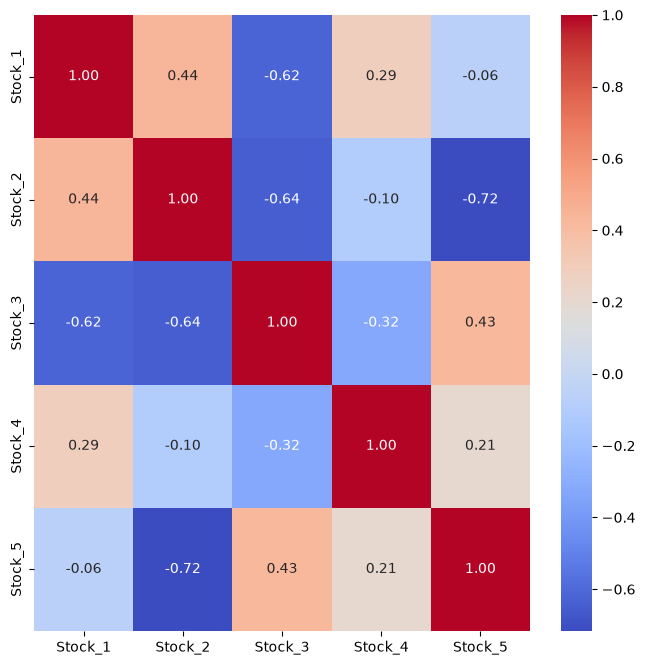

In [31]:
import seaborn  as sns 
corr = independent_variable[['Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']].corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

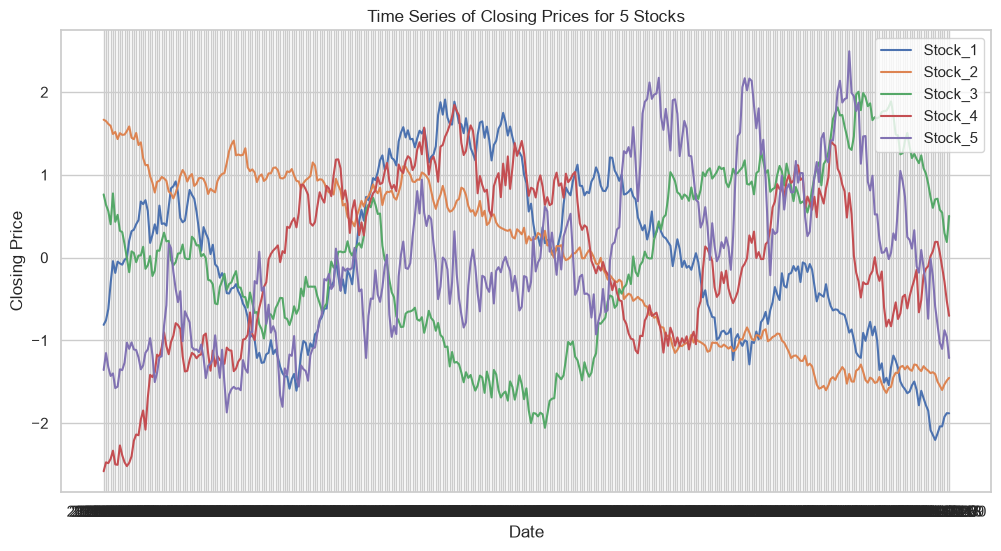

In [73]:
sns.set(style = 'whitegrid')

independent_variable.set_index('Time', inplace=True)


plt.figure(figsize = (12,6))
for column in independent_variable.columns:
    plt.plot(independent_variable.index, independent_variable[column], label = column)

plt.title('Time Series of Closing Prices for 5 Stocks')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

In [76]:
y = independent_variable['Stock_5']
x = independent_variable[['Stock_1', 'Stock_2', 'Stock_3', 'Stock_4']]

In [52]:
print(x.shape)
print(y.shape)

(365, 4)
(365,)


In [34]:
from sklearn.model_selection import train_test_split 
from sklearn import linear_model

In [77]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3, random_state=None)

In [78]:
lr = linear_model.LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.35,-0.78, 0.14, 0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Stock_1','Stock_2','Stock_3','Stock_4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.01134
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lr.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.5893845932268783
MSE: 0.5109961564762736
RMSE: 0.7148399516509087
R²: 0.5363934813793989


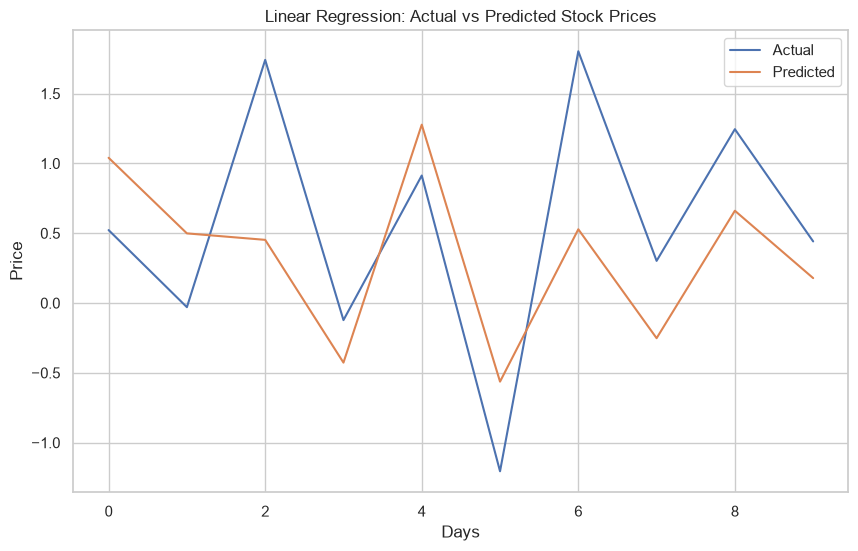

In [90]:
plt.figure(figsize=(10, 6))

plt.plot(y_test.iloc[:10].values, label='Actual')
plt.plot(y_pred[:10], label='Predicted')

plt.title('Linear Regression: Actual vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()



In [138]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
dt = DecisionTreeRegressor(
    max_depth=12,
    random_state=42,
    splitter='random',
    criterion='absolute_error'
)

# Train
dt.fit(x_train, y_train)

# Predict
y_pred_dt = dt.predict(x_test)

# Evaluation
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

MAE: 0.4270960304779643
RMSE: 0.7148399516509087
R²: 0.6795542398089496


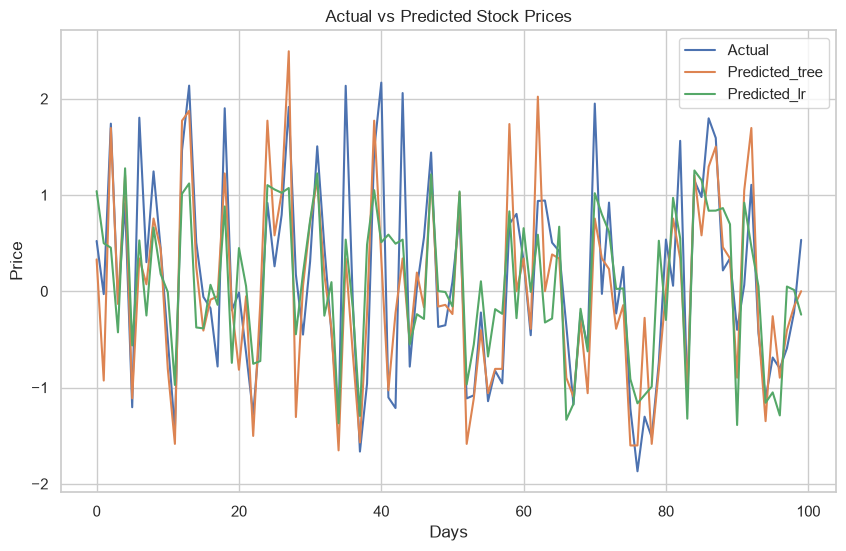

In [141]:
plt.figure(figsize=(10, 6))

plt.plot(y_test.iloc[:100].values, label='Actual')
plt.plot(y_pred_dt[:100], label='Predicted_tree')
plt.plot(y_pred[:100], label='Predicted_lr')

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()